# 📈 [V7.2] Forecasting Tingkat NEET dengan Model Hybrid (Perbaikan Final)

Ini adalah notebook versi perbaikan final yang mengatasi masalah `NaN` pada forecast dan bertujuan untuk mengoptimalkan kembali skor MAPE dengan pencarian hyperparameter yang lebih luas.

**Metodologi:**
1. **ARIMA:** Untuk memodelkan tren linear.
2. **Feature Engineering & Scaling:** Membuat fitur dari residual dan melakukan scaling.
3. **XGBoost & Grid Search Diperluas:** Menggunakan pencarian parameter yang lebih luas untuk menemukan model XGBoost yang paling robust.

## 1. Persiapan Pustaka

In [ ]:
import pandas as pd
import numpy as np
import pmdarima as pm
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Memuat dan Membagi Data

In [ ]:
file_path = 'Data/indonesia_neet_youth_rate.csv'
df = pd.read_csv(file_path)
df['ds'] = pd.to_datetime(df['Year'], format='%Y')
df = df.set_index('ds')
df = df.sort_index()
data_series = df['NEET Youth Rate (%)']

train_cutoff = '2018'
train_data = data_series[:train_cutoff]
test_data = data_series[str(int(train_cutoff)+1):]

## 3. Tahap 1: Pemodelan Linear dengan `auto_arima`

In [ ]:
arima_model = pm.auto_arima(train_data, seasonal=False, stepwise=True, suppress_warnings=True, trace=False)
print(f"Model ARIMA Terbaik: {arima_model.order}")

Model ARIMA Terbaik: (0, 1, 0)


## 4. Tahap 2: Feature Engineering, Scaling, & Optimasi XGBoost (Diperluas)

In [ ]:
arima_residuals = arima_model.resid()

residual_df = pd.DataFrame(arima_residuals, columns=['residual'])
residual_df['lag_1'] = residual_df['residual'].shift(1)
residual_df['lag_2'] = residual_df['residual'].shift(2)
residual_df['lag_3'] = residual_df['residual'].shift(3)
residual_df['time_trend'] = range(len(residual_df))
residual_df.dropna(inplace=True)

X_train_resid = residual_df[['lag_1', 'lag_2', 'lag_3', 'time_trend']]
y_train_resid = residual_df['residual']

scaler = StandardScaler()
X_train_resid_scaled = scaler.fit_transform(X_train_resid)

# Perluas rentang parameter untuk GridSearch
param_grid_xgb = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_grid_search = GridSearchCV(XGBRegressor(objective='reg:squarederror'), param_grid_xgb, cv=3, scoring='neg_mean_squared_error', verbose=0, n_jobs=-1)
xgb_grid_search.fit(X_train_resid_scaled, y_train_resid)

best_xgb = xgb_grid_search.best_estimator_
print(f"Parameter XGBoost Terbaik: {xgb_grid_search.best_params_}")

Parameter XGBoost Terbaik: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 50, 'subsample': 1.0}


## 5. Membuat Prediksi Gabungan pada Data Test (Validasi)

In [ ]:
arima_predictions_test = arima_model.predict(n_periods=len(test_data))
arima_predictions_test = pd.Series(arima_predictions_test, index=test_data.index)

last_residuals_for_pred_test = list(arima_residuals.iloc[-3:])
start_time_trend_test = len(residual_df) + 3
xgb_predictions_test = []

for i in range(len(test_data)):
    features_df_test = pd.DataFrame({
        'lag_1': [last_residuals_for_pred_test[2]],
        'lag_2': [last_residuals_for_pred_test[1]],
        'lag_3': [last_residuals_for_pred_test[0]],
        'time_trend': [start_time_trend_test + i]
    })
    features_scaled = scaler.transform(features_df_test)
    pred_resid = best_xgb.predict(features_scaled)[0]
    xgb_predictions_test.append(pred_resid)
    last_residuals_for_pred_test.pop(0)
    last_residuals_for_pred_test.append(pred_resid)

xgb_predictions_test = pd.Series(xgb_predictions_test, index=test_data.index)
hybrid_predictions_final = arima_predictions_test + xgb_predictions_test

## 6. Evaluasi & Visualisasi Validasi

In [ ]:
rmse_final = np.sqrt(mean_squared_error(test_data, hybrid_predictions_final))
mape_final = mean_absolute_percentage_error(test_data, hybrid_predictions_final)
print(f"--- Metrik Evaluasi pada Data Test ---")
print(f"RMSE: {rmse_final:.4f}")
print(f"MAPE: {mape_final:.2%}")

--- Metrik Evaluasi pada Data Test ---
RMSE: 0.9926
MAPE: 4.53%


--- 
## 7. Forecasting Masa Depan (2025-2029)

In [ ]:
n_forecast = 5
arima_full_forecast = np.array(arima_model.predict(n_periods=len(test_data) + n_forecast))
last_residuals = list(arima_residuals.iloc[-3:])
start_time_trend = len(residual_df) + 3
xgb_full_forecast = []

for i in range(len(test_data) + n_forecast):
    features_df = pd.DataFrame({
        'lag_1': [last_residuals[2]],
        'lag_2': [last_residuals[1]],
        'lag_3': [last_residuals[0]],
        'time_trend': [start_time_trend + i]
    })
    features_scaled = scaler.transform(features_df)
    pred_resid = best_xgb.predict(features_scaled)[0]
    xgb_full_forecast.append(pred_resid)
    last_residuals.pop(0)
    last_residuals.append(pred_resid)

xgb_full_forecast = np.array(xgb_full_forecast)
hybrid_full_forecast = arima_full_forecast + xgb_full_forecast

future_index = pd.date_range(start=test_data.index[-1] + pd.DateOffset(years=1), periods=n_forecast, freq='A')
future_forecast_df = pd.DataFrame({'Forecast': hybrid_full_forecast[-n_forecast:]}, index=future_index)

print("--- Hasil Forecast Tingkat NEET (2025-2029) ---")
print(future_forecast_df.round(2))

--- Hasil Forecast Tingkat NEET (2025-2029) ---
            Forecast
2025-12-31     21.32
2026-12-31     21.08
2027-12-31     21.52
2028-12-31     21.32
2029-12-31     21.08


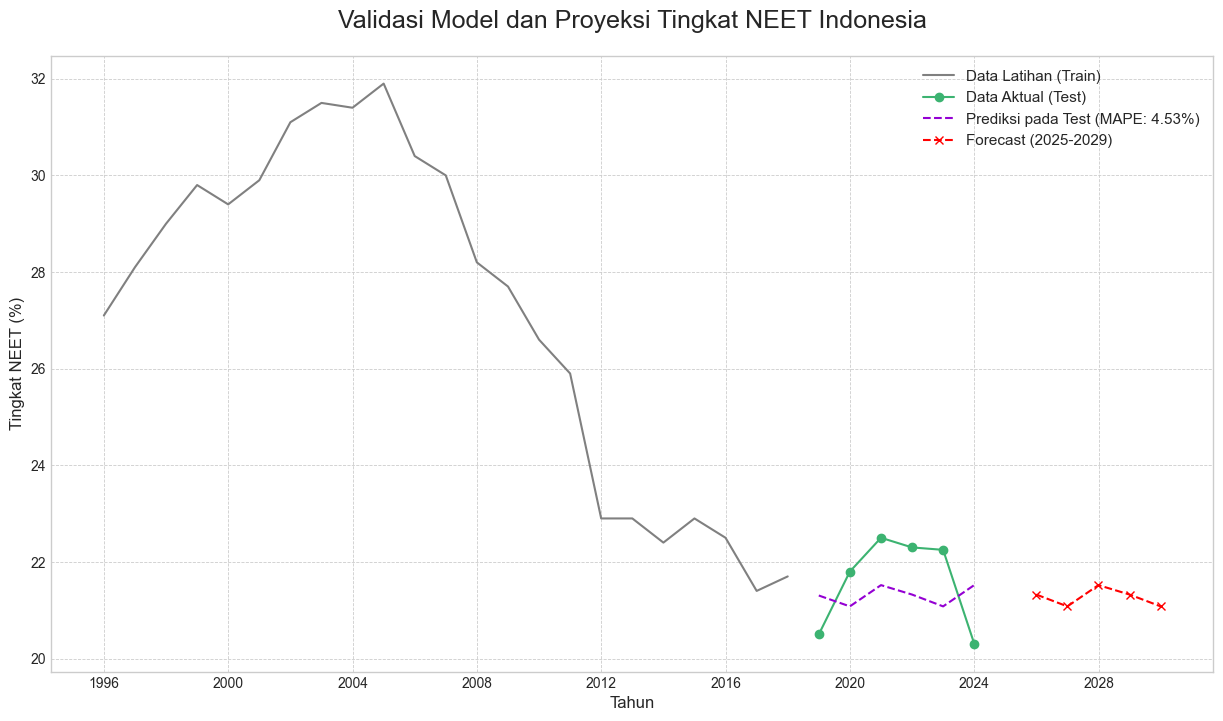

In [ ]:
plt.figure(figsize=(15, 8))
plt.plot(train_data.index, train_data, label='Data Latihan (Train)', color='gray')
plt.plot(test_data.index, test_data, label='Data Aktual (Test)', color='mediumseagreen', marker='o', linestyle='-')
plt.plot(hybrid_predictions_final.index, hybrid_predictions_final, label=f'Prediksi pada Test (MAPE: {mape_final:.2%})', color='darkviolet', linestyle='--')
plt.plot(future_forecast_df.index, future_forecast_df['Forecast'], label='Forecast (2025-2029)', color='red', linestyle='--', marker='x')

plt.title('Validasi Model dan Proyeksi Tingkat NEET Indonesia', fontsize=18, pad=20)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Tingkat NEET (%)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, which='major', linestyle='--', linewidth='0.6')
plt.show()